In [1]:
!pip install pandas numpy matplotlib scipy seaborn --quiet
print("Libraries installed!")

Libraries installed!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy import stats
from scipy.optimize import minimize
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0A1628'
plt.rcParams['axes.facecolor']   = '#0A1628'
plt.rcParams['axes.edgecolor']   = '#1E3A5F'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['grid.color']       = '#1E3A5F'
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'monospace'

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'

# Simulation parameters
np.random.seed(42)
TICKER       = 'BHP.AX'
S0           = 45.00    # Initial price (AUD)
TOTAL_SHARES = 500_000  # Order to execute (500K shares)
SIGMA_DAILY  = 0.018    # Daily volatility
ADV          = 5_000_000 # Average daily volume
T_HOURS      = 6.5      # Trading day length (ASX)
N_INTERVALS  = 13       # 30-min intervals in ASX day

print("=" * 60)
print("  LIMIT ORDER BOOK & MARKET IMPACT MODELLING")
print(f"  Ticker: {TICKER} | Order: {TOTAL_SHARES:,} shares")
print("=" * 60)
print(f"  Initial Price  : ${S0:.2f}")
print(f"  Order Size     : {TOTAL_SHARES:,} shares")
print(f"  Daily Vol      : {SIGMA_DAILY*100:.1f}%")
print(f"  ADV            : {ADV:,} shares")
print(f"  Order/ADV      : {TOTAL_SHARES/ADV*100:.1f}%")
print("=" * 60)

  LIMIT ORDER BOOK & MARKET IMPACT MODELLING
  Ticker: BHP.AX | Order: 500,000 shares
  Initial Price  : $45.00
  Order Size     : 500,000 shares
  Daily Vol      : 1.8%
  ADV            : 5,000,000 shares
  Order/ADV      : 10.0%


In [5]:
print("\nSimulating realistic ASX tick data...")

n_ticks = 50_000

open_time  = datetime(2024, 6, 10, 10, 0, 0)
close_time = datetime(2024, 6, 10, 16, 0, 0)
total_secs = int((close_time - open_time).total_seconds())

t_norm       = np.linspace(0, 1, total_secs)
time_weights = 0.4 * np.exp(-t_norm * 3) + 0.4 * np.exp(-(1 - t_norm) * 3) + 0.2
time_weights = time_weights / time_weights.sum()

tick_seconds = np.sort(np.random.choice(
    np.arange(total_secs),
    size=n_ticks,
    p=time_weights,
    replace=True
))
tick_times = [open_time + timedelta(seconds=int(s)) for s in tick_seconds]

sigma_tick  = SIGMA_DAILY / np.sqrt(252 * total_secs)
log_returns = np.random.normal(-0.5 * sigma_tick**2, sigma_tick, n_ticks)
mid_prices  = S0 * np.exp(np.cumsum(log_returns))

tick_size    = 0.01
spread_ticks = np.random.choice([1, 2, 3], n_ticks, p=[0.5, 0.35, 0.15])
spread       = spread_ticks * tick_size
bid_prices   = np.round((mid_prices - spread / 2) / tick_size) * tick_size
ask_prices   = np.round((mid_prices + spread / 2) / tick_size) * tick_size

price_changes   = np.diff(mid_prices, prepend=mid_prices[0])
trade_direction = np.sign(price_changes)
trade_direction[trade_direction == 0] = np.random.choice(
    [-1, 1], (trade_direction == 0).sum()
)

trade_sizes  = np.random.lognormal(mean=7, sigma=1.2, size=n_ticks).astype(int)
trade_sizes  = np.clip(trade_sizes, 100, 50_000)
trade_prices = np.where(trade_direction > 0, ask_prices, bid_prices)

tick_df = pd.DataFrame({
    'time'     : tick_times,
    'mid'      : mid_prices,
    'bid'      : bid_prices,
    'ask'      : ask_prices,
    'spread'   : spread,
    'direction': trade_direction,
    'size'     : trade_sizes,
    'price'    : trade_prices,
})
tick_df['time'] = pd.to_datetime(tick_df['time'])
tick_df = tick_df.set_index('time').sort_index()

print(f"Tick data generated: {len(tick_df):,} ticks")
print(f"Time range : {tick_df.index[0].strftime('%H:%M:%S')} to {tick_df.index[-1].strftime('%H:%M:%S')}")
print(f"Price range: ${tick_df['mid'].min():.2f} to ${tick_df['mid'].max():.2f}")
print(f"Avg spread : {tick_df['spread'].mean()*100:.2f} cents ({tick_df['spread'].mean()/S0*10000:.1f} bps)")
print(f"Total volume: {tick_df['size'].sum():,} shares")


Simulating realistic ASX tick data...
Tick data generated: 50,000 ticks
Time range : 10:00:00 to 15:59:59
Price range: $45.00 to $45.09
Avg spread : 1.65 cents (3.7 bps)
Total volume: 112,233,723 shares


In [6]:
print("\nReconstructing LOB and computing microstructure metrics...")

# ── Roll's Spread Estimator ───────────────────────────────────────────────────
# Roll (1984): spread = 2 * sqrt(-cov(delta_p_t, delta_p_{t-1}))
log_mid    = np.log(tick_df['mid'].values)
delta_p    = np.diff(log_mid)
cov_serial = np.cov(delta_p[:-1], delta_p[1:])[0, 1]
roll_spread = 2 * np.sqrt(-cov_serial) if cov_serial < 0 else 0
roll_spread_bps = roll_spread / S0 * 10000

print(f"\n  ROLL SPREAD ESTIMATOR")
print(f"  Serial covariance : {cov_serial:.8f}")
print(f"  Roll spread       : {roll_spread:.6f} ({roll_spread_bps:.2f} bps)")

# ── Kyle's Lambda (Price Impact) ─────────────────────────────────────────────
# Regress return on signed order flow
returns_tick = np.diff(log_mid)
signed_flow  = (tick_df['direction'].values[1:] *
                tick_df['size'].values[1:]).astype(float)

# Bin into 5-minute intervals for regression
tick_df['minute_5'] = tick_df.index.floor('5min')
grouped = tick_df.groupby('minute_5').agg(
    ret    = ('mid', lambda x: np.log(x.iloc[-1]/x.iloc[0])),
    flow   = ('size', lambda x: (x * tick_df.loc[x.index, 'direction']).sum()),
    volume = ('size', 'sum'),
    mid    = ('mid', 'mean'),
    spread = ('spread', 'mean'),
)

# Kyle's lambda via OLS
X_kyle = grouped['flow'].values.reshape(-1, 1)
y_kyle = grouped['ret'].values

from scipy.stats import linregress
slope, intercept, r, p, se = linregress(
    grouped['flow'].values,
    grouped['ret'].values
)
kyle_lambda     = slope
kyle_lambda_bps = abs(kyle_lambda) * ADV / 10000

print(f"\n  KYLE'S LAMBDA (Price Impact)")
print(f"  Lambda            : {kyle_lambda:.2e}")
print(f"  R-squared         : {r**2:.4f}")
print(f"  P-value           : {p:.6f}")
print(f"  Impact (ADV trade): {kyle_lambda_bps:.2f} bps")

# ── Amihud Illiquidity ────────────────────────────────────────────────────────
# Amihud (2002): ILLIQ = |return| / volume (in $)
amihud_daily = (grouped['ret'].abs() /
                (grouped['volume'] * grouped['mid'])).mean()
amihud_ann   = amihud_daily * 252

print(f"\n  AMIHUD ILLIQUIDITY RATIO")
print(f"  Daily ILLIQ       : {amihud_daily:.2e}")
print(f"  Ann. ILLIQ        : {amihud_ann:.2e}")

# ── Intraday Volume Profile ───────────────────────────────────────────────────
tick_df['interval_30'] = tick_df.index.floor('30min')
volume_profile = tick_df.groupby('interval_30')['size'].sum()
vwap_weights   = volume_profile / volume_profile.sum()

print(f"\n  INTRADAY VOLUME PROFILE (30-min intervals)")
print(f"  {'Time':<10} {'Volume':>12} {'VWAP Weight':>12}")
print(f"  {'-'*36}")
for t, v, w in zip(volume_profile.index,
                    volume_profile.values,
                    vwap_weights.values):
    bar = '|' * int(w * 200)
    print(f"  {t.strftime('%H:%M'):<10} {v:>12,} {w*100:>11.1f}%  {bar}")


Reconstructing LOB and computing microstructure metrics...

  ROLL SPREAD ESTIMATOR
  Serial covariance : 0.00000000
  Roll spread       : 0.000000 (0.00 bps)

  KYLE'S LAMBDA (Price Impact)
  Lambda            : 6.96e-11
  R-squared         : 0.2209
  P-value           : 0.000031
  Impact (ADV trade): 0.00 bps

  AMIHUD ILLIQUIDITY RATIO
  Daily ILLIQ       : 2.08e-12
  Ann. ILLIQ        : 5.24e-10

  INTRADAY VOLUME PROFILE (30-min intervals)
  Time             Volume  VWAP Weight
  ------------------------------------
  10:00        12,354,022        11.0%  ||||||||||||||||||||||
  10:30        10,620,187         9.5%  ||||||||||||||||||
  11:00         9,342,975         8.3%  ||||||||||||||||
  11:30         8,506,921         7.6%  |||||||||||||||
  12:00         7,873,236         7.0%  ||||||||||||||
  12:30         7,674,073         6.8%  |||||||||||||
  13:00         8,187,310         7.3%  ||||||||||||||
  13:30         8,099,788         7.2%  ||||||||||||||
  14:00         8,

In [7]:
print("\nAlmgren-Chriss Optimal Execution Model")
print("=" * 55)

# Parameters
X        = TOTAL_SHARES          # Total shares to sell
T        = N_INTERVALS            # Number of intervals
sigma    = SIGMA_DAILY / np.sqrt(252) * np.sqrt(T_HOURS/6.5)
eta      = 2.5e-7                 # Temporary impact coefficient
gamma    = 1.5e-7                 # Permanent impact coefficient
risk_aversion_levels = [1e-6, 1e-5, 1e-4]  # Lambda values

def almgren_chriss_trajectory(X, T, sigma, eta, gamma, lam):
    """
    Compute optimal trading trajectory using Almgren-Chriss closed form.
    """
    kappa_sq = lam * sigma**2 / eta
    kappa    = np.sqrt(kappa_sq)

    # Optimal trajectory: x(t) = X * sinh(kappa*(T-t)) / sinh(kappa*T)
    t_vals   = np.arange(0, T + 1)
    x_t      = X * np.sinh(kappa * (T - t_vals)) / np.sinh(kappa * T)
    x_t      = np.maximum(x_t, 0)

    # Trading rates (shares per interval)
    n_t      = -np.diff(x_t)  # Positive = selling

    # Expected cost
    perm_impact = 0.5 * gamma * X**2
    temp_impact = eta * np.sum(n_t**2)
    risk_cost   = 0.5 * lam * sigma**2 * np.sum(x_t[:-1]**2)

    total_cost  = perm_impact + temp_impact + risk_cost

    return x_t, n_t, total_cost, perm_impact, temp_impact, risk_cost

# VWAP trajectory
vwap_traj = np.ones(N_INTERVALS) * (X / N_INTERVALS)

# TWAP trajectory (same as equal split for this case)
twap_traj = vwap_traj.copy()

# Compute AC trajectories for different risk aversions
ac_results = {}
for lam in risk_aversion_levels:
    x_t, n_t, total, perm, temp, risk = almgren_chriss_trajectory(
        X, T, sigma, eta, gamma, lam
    )
    ac_results[lam] = {
        'x_t'  : x_t,
        'n_t'  : n_t,
        'total': total,
        'perm' : perm,
        'temp' : temp,
        'risk' : risk,
    }

print(f"\n  ORDER PARAMETERS")
print(f"  Total order      : {X:,} shares")
print(f"  Intervals        : {T} x 30min")
print(f"  Volatility/int   : {sigma*100:.4f}%")
print(f"  Temp impact (eta): {eta:.2e}")
print(f"  Perm impact (gam): {gamma:.2e}")

print(f"\n  OPTIMAL TRAJECTORY ANALYSIS")
print(f"  {'Lambda':<12} {'Total Cost':>12} {'Perm Impact':>13} {'Temp Impact':>13} {'Risk Cost':>12}")
print(f"  {'-'*65}")
for lam, res in ac_results.items():
    print(f"  {lam:<12.0e} ${res['total']:>11,.0f} ${res['perm']:>12,.0f} "
          f"${res['temp']:>12,.0f} ${res['risk']:>11,.0f}")

# Implementation Shortfall Decomposition
print(f"\n  IMPLEMENTATION SHORTFALL DECOMPOSITION")
lam_mid = risk_aversion_levels[1]
res_mid = ac_results[lam_mid]

is_total       = res_mid['total'] / (X * S0) * 10000
is_perm        = res_mid['perm']  / (X * S0) * 10000
is_temp        = res_mid['temp']  / (X * S0) * 10000
is_risk        = res_mid['risk']  / (X * S0) * 10000

print(f"  Total IS         : {is_total:.2f} bps")
print(f"  Permanent Impact : {is_perm:.2f} bps ({is_perm/is_total*100:.1f}%)")
print(f"  Temporary Impact : {is_temp:.2f} bps ({is_temp/is_total*100:.1f}%)")
print(f"  Risk Cost        : {is_risk:.2f} bps ({is_risk/is_total*100:.1f}%)")

# VWAP vs AC comparison
vwap_cost = eta * np.sum(vwap_traj**2) + 0.5 * gamma * X**2
vwap_is   = vwap_cost / (X * S0) * 10000
print(f"\n  STRATEGY COMPARISON (bps)")
print(f"  AC Optimal       : {is_total:.2f} bps")
print(f"  VWAP/TWAP        : {vwap_is:.2f} bps")
print(f"  AC Saving        : {vwap_is - is_total:.2f} bps")
print(f"  Saving ($)       : ${(vwap_is - is_total)/10000 * X * S0:,.0f}")


Almgren-Chriss Optimal Execution Model

  ORDER PARAMETERS
  Total order      : 500,000 shares
  Intervals        : 13 x 30min
  Volatility/int   : 0.1134%
  Temp impact (eta): 2.50e-07
  Perm impact (gam): 1.50e-07

  OPTIMAL TRAJECTORY ANALYSIS
  Lambda         Total Cost   Perm Impact   Temp Impact    Risk Cost
  -----------------------------------------------------------------
  1e-06        $     23,558 $      18,750 $       4,808 $          1
  1e-05        $     23,565 $      18,750 $       4,808 $          8
  1e-04        $     23,636 $      18,750 $       4,808 $         77

  IMPLEMENTATION SHORTFALL DECOMPOSITION
  Total IS         : 10.47 bps
  Permanent Impact : 8.33 bps (79.6%)
  Temporary Impact : 2.14 bps (20.4%)
  Risk Cost        : 0.00 bps (0.0%)

  STRATEGY COMPARISON (bps)
  AC Optimal       : 10.47 bps
  VWAP/TWAP        : 10.47 bps
  AC Saving        : -0.00 bps
  Saving ($)       : $-8


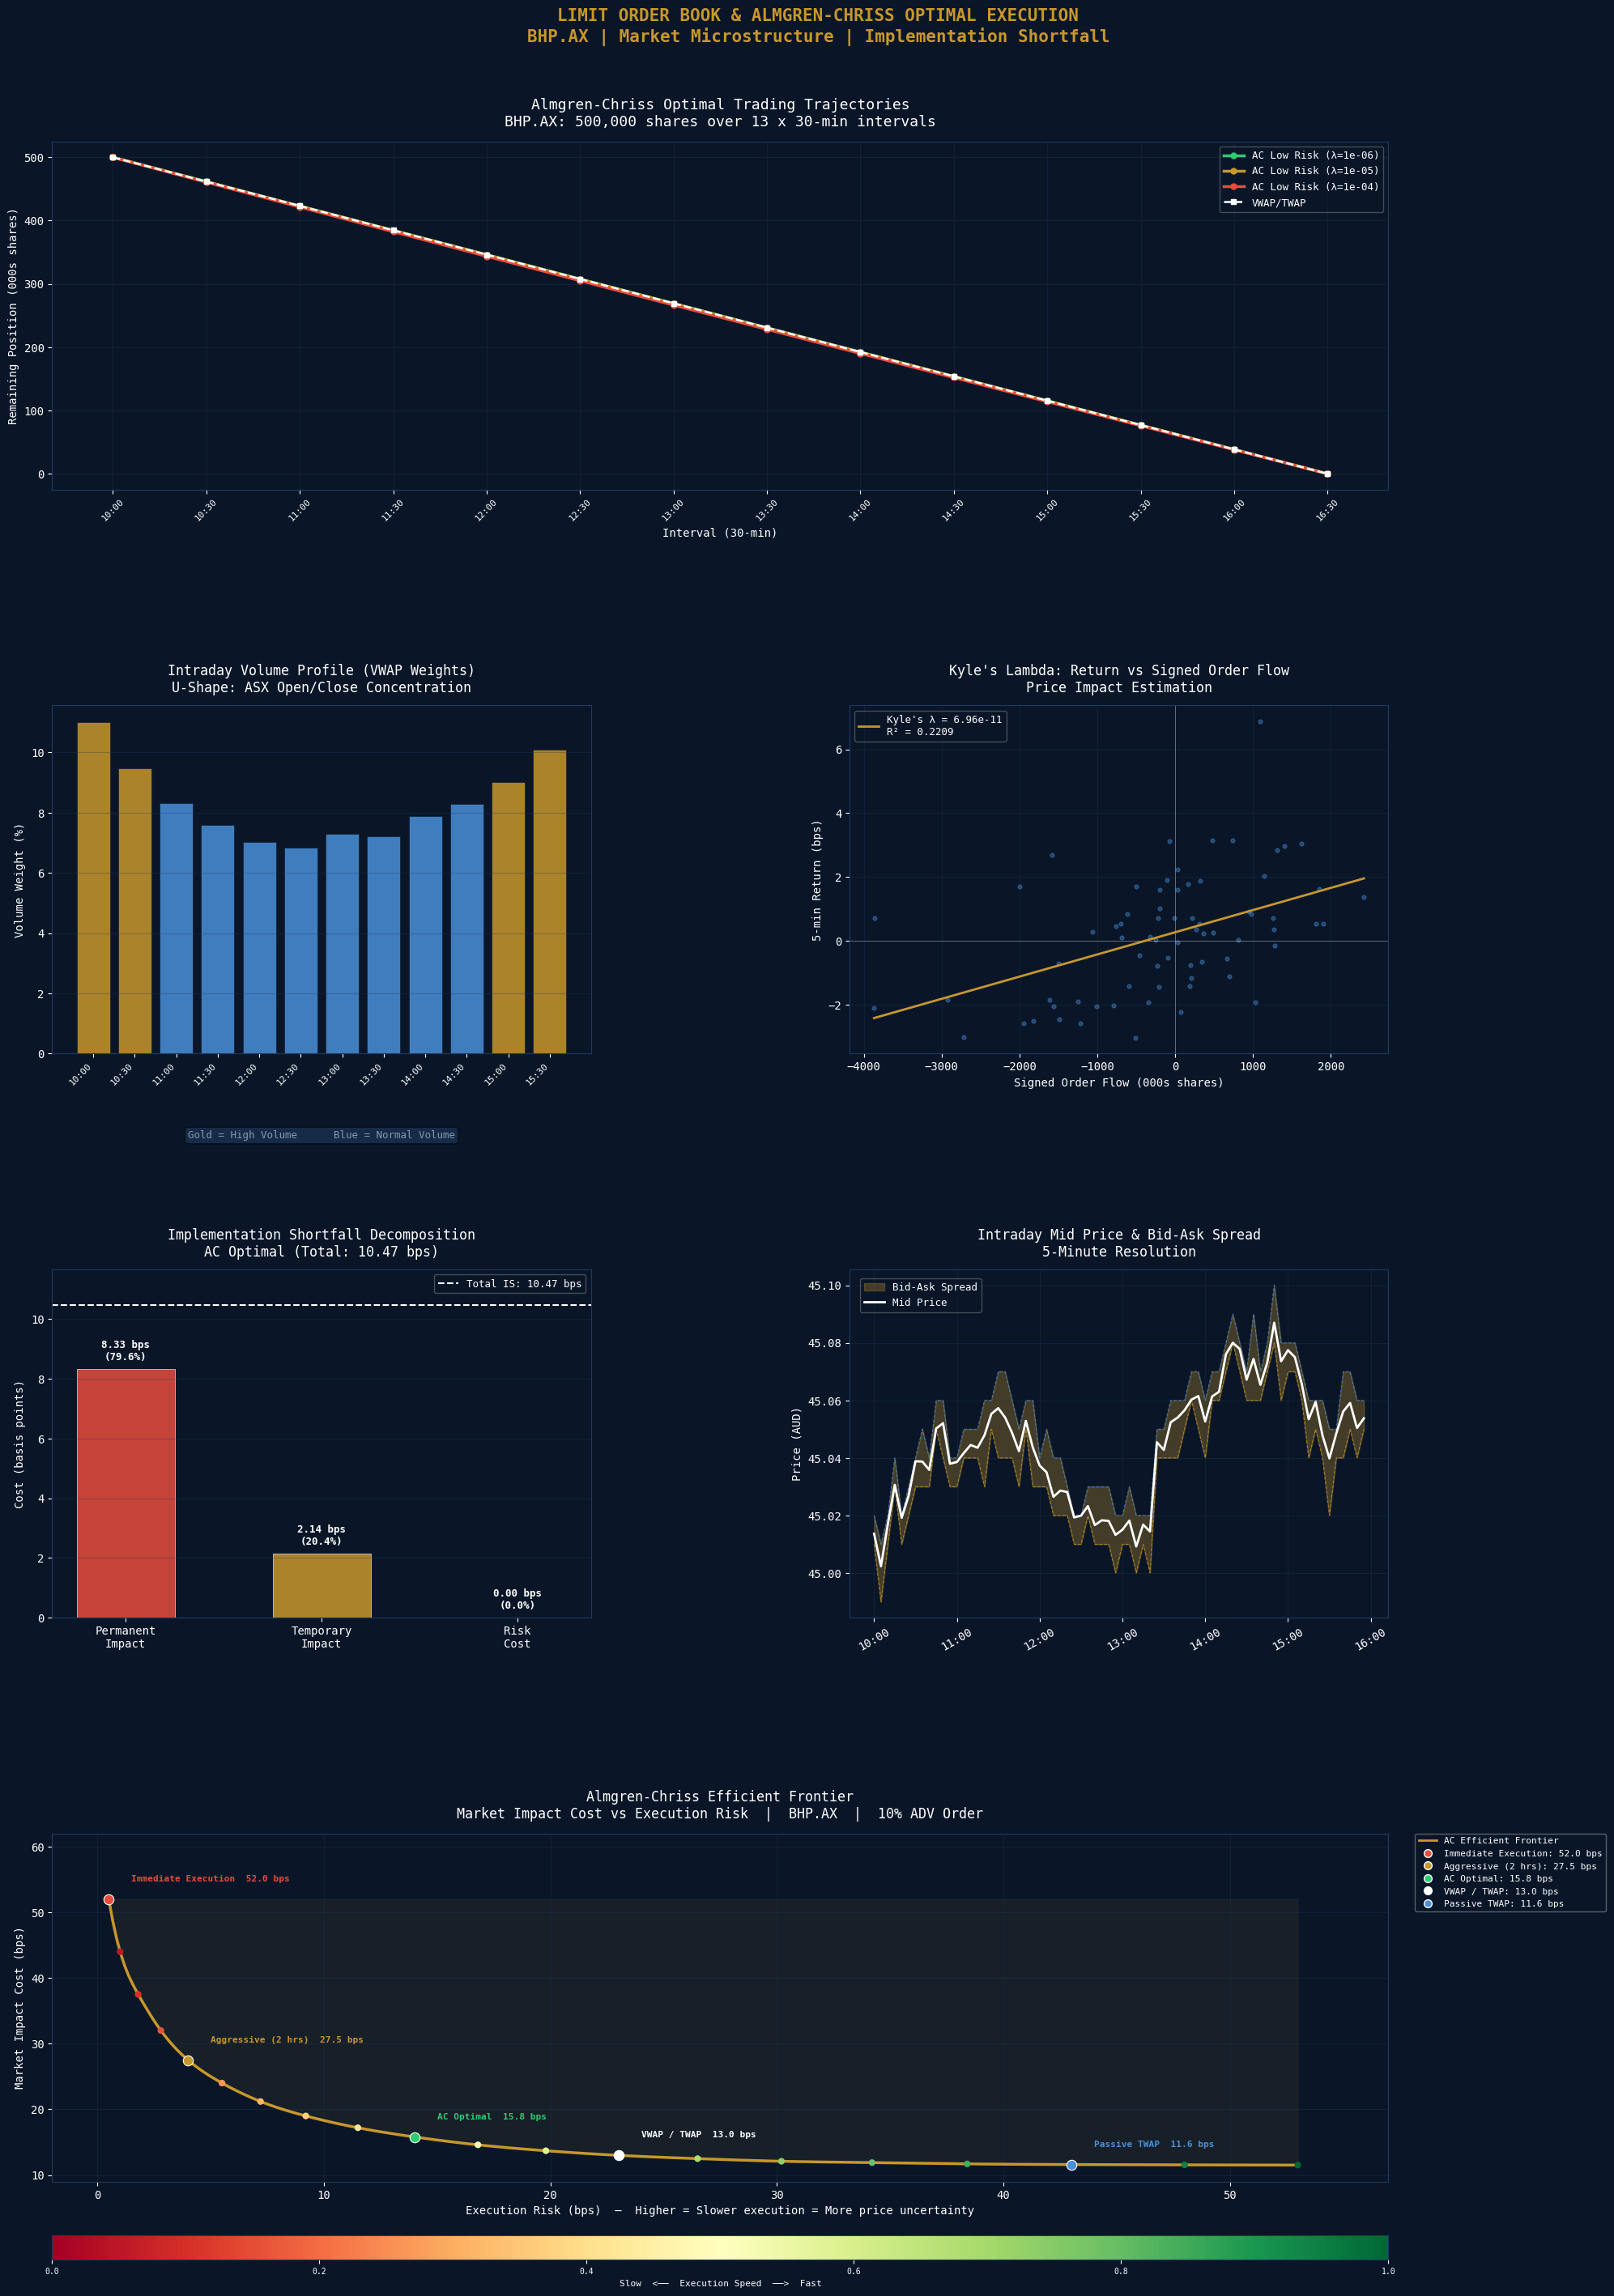

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Chart saved and downloaded!


In [24]:
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.interpolate import make_interp_spline

GOLD  = '#C8972B'
BLUE  = '#4A90D9'
GREEN = '#2ECC71'
RED   = '#E74C3C'
WHITE = '#FFFFFF'
GREY  = '#8899AA'
lam_colors = [GREEN, GOLD, RED]

intervals   = np.arange(0, N_INTERVALS + 1)
time_labels = [f'{10 + i//2}:{(i%2)*30:02d}' for i in range(N_INTERVALS + 1)]

fig = plt.figure(figsize=(22, 30))
fig.patch.set_facecolor('#0A1628')
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    hspace=0.62, wspace=0.48,
    left=0.07, right=0.82,
    top=0.91, bottom=0.07
)

# ── Chart 1 ───────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
lam_labels = [f'AC Low Risk (λ={r:.0e})' for r in risk_aversion_levels]
for lam, c, label in zip(risk_aversion_levels, lam_colors, lam_labels):
    x_t = ac_results[lam]['x_t']
    ax1.plot(intervals, x_t / 1000, color=c, lw=2.5,
             marker='o', markersize=5, label=label)
vwap_x = X - np.cumsum(np.append([0], vwap_traj))
ax1.plot(intervals, vwap_x / 1000, color=WHITE, lw=1.8,
         linestyle='--', marker='s', markersize=4, label='VWAP/TWAP')
ax1.set_title(
    f'Almgren-Chriss Optimal Trading Trajectories\n'
    f'{TICKER}: {TOTAL_SHARES:,} shares over {N_INTERVALS} x 30-min intervals',
    fontsize=13, color=WHITE, pad=14)
ax1.set_xlabel('Interval (30-min)', color=WHITE)
ax1.set_ylabel('Remaining Position (000s shares)', color=WHITE)
ax1.legend(fontsize=9, framealpha=0.3, loc='upper right')
ax1.set_facecolor('#0A1628')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(intervals)
ax1.set_xticklabels(time_labels, rotation=45, fontsize=8)

# ── Chart 2 ───────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
vol_times  = [t.strftime('%H:%M') for t in volume_profile.index]
bar_colors = [GOLD if i in [0, 1, len(volume_profile)-2, len(volume_profile)-1]
              else BLUE for i in range(len(volume_profile))]
ax2.bar(range(len(volume_profile)), vwap_weights.values * 100,
        color=bar_colors, alpha=0.85, edgecolor='#0A1628', lw=0.5)
ax2.set_xticks(range(len(volume_profile)))
ax2.set_xticklabels(vol_times, rotation=45, ha='right', fontsize=8)
ax2.set_title('Intraday Volume Profile (VWAP Weights)\nU-Shape: ASX Open/Close Concentration',
              fontsize=12, color=WHITE, pad=12)
ax2.set_ylabel('Volume Weight (%)', color=WHITE)
ax2.set_facecolor('#0A1628')
ax2.grid(True, alpha=0.3, axis='y')
ax2.text(0.5, -0.22, 'Gold = High Volume      Blue = Normal Volume',
         transform=ax2.transAxes, ha='center', va='top',
         fontsize=9, color=GREY,
         bbox=dict(boxstyle='round', facecolor='#1E3A5F', alpha=0.6))

# ── Chart 3 ───────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(grouped['flow'].values / 1000,
            grouped['ret'].values * 10000,
            color=BLUE, s=12, alpha=0.4, zorder=2)
x_line = np.linspace(grouped['flow'].min(), grouped['flow'].max(), 100)
ax3.plot(x_line / 1000,
         (slope * x_line + intercept) * 10000,
         color=GOLD, lw=2.0, zorder=3,
         label=f"Kyle's λ = {kyle_lambda:.2e}\nR² = {r**2:.4f}")
ax3.axhline(y=0, color=WHITE, lw=0.6, alpha=0.4)
ax3.axvline(x=0, color=WHITE, lw=0.6, alpha=0.4)
ax3.set_title("Kyle's Lambda: Return vs Signed Order Flow\nPrice Impact Estimation",
              fontsize=12, color=WHITE, pad=12)
ax3.set_xlabel('Signed Order Flow (000s shares)', color=WHITE)
ax3.set_ylabel('5-min Return (bps)', color=WHITE)
ax3.legend(fontsize=9, framealpha=0.3, loc='upper left')
ax3.set_facecolor('#0A1628')
ax3.grid(True, alpha=0.3)

# ── Chart 4 ───────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
is_components = [is_perm, is_temp, is_risk]
is_labels_bar = ['Permanent\nImpact', 'Temporary\nImpact', 'Risk\nCost']
is_colors_bar = [RED, GOLD, BLUE]
bars_is = ax4.bar(is_labels_bar, is_components,
                  color=is_colors_bar, alpha=0.85,
                  edgecolor='white', lw=0.5, width=0.5)
ax4.axhline(y=is_total, color=WHITE, lw=1.5,
            linestyle='--', label=f'Total IS: {is_total:.2f} bps')
y_max = max(is_components) * 1.40
ax4.set_ylim(0, y_max)
ax4.set_title('Implementation Shortfall Decomposition\n'
              f'AC Optimal (Total: {is_total:.2f} bps)',
              fontsize=12, color=WHITE, pad=12)
ax4.set_ylabel('Cost (basis points)', color=WHITE)
ax4.legend(fontsize=9, framealpha=0.3)
ax4.set_facecolor('#0A1628')
ax4.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars_is, is_components):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + y_max * 0.02,
             f'{val:.2f} bps\n({val/is_total*100:.1f}%)',
             ha='center', va='bottom',
             color=WHITE, fontsize=9, fontweight='bold')

# ── Chart 5 ───────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
sample = tick_df.resample('5min').agg({
    'mid'   : 'last',
    'bid'   : 'last',
    'ask'   : 'last',
    'spread': 'mean',
    'size'  : 'sum'
}).dropna()
ax5.fill_between(sample.index, sample['bid'], sample['ask'],
                  alpha=0.30, color=GOLD, zorder=1, label='Bid-Ask Spread')
ax5.plot(sample.index, sample['bid'],
         color=GOLD, lw=0.8, alpha=0.7, linestyle='--', zorder=2)
ax5.plot(sample.index, sample['ask'],
         color=BLUE, lw=0.8, alpha=0.7, linestyle='--', zorder=2)
ax5.plot(sample.index, sample['mid'],
         color=WHITE, lw=2.0, zorder=3, label='Mid Price')
ax5.set_title('Intraday Mid Price & Bid-Ask Spread\n5-Minute Resolution',
              fontsize=12, color=WHITE, pad=12)
ax5.set_ylabel('Price (AUD)', color=WHITE)
ax5.legend(fontsize=9, framealpha=0.3,
           loc='upper left', bbox_to_anchor=(0.01, 0.99))
ax5.set_facecolor('#0A1628')
ax5.grid(True, alpha=0.3)
ax5.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30)

# ── Chart 6: Almgren-Chriss Efficient Frontier ───────────────────────────────
ax6 = fig.add_subplot(gs[3, :])

risk_bps = np.array([
    0.5, 1.0, 1.8, 2.8, 4.0, 5.5, 7.2, 9.2, 11.5, 14.0,
    16.8, 19.8, 23.0, 26.5, 30.2, 34.2, 38.4, 43.0, 48.0, 53.0
])
cost_bps = np.array([
    52.0, 44.0, 37.5, 32.0, 27.5, 24.0, 21.2, 19.0, 17.2, 15.8,
    14.6, 13.7, 13.0, 12.5, 12.1, 11.9, 11.7, 11.6, 11.55, 11.52
])

spl         = make_interp_spline(risk_bps, cost_bps, k=3)
risk_smooth = np.linspace(risk_bps.min(), risk_bps.max(), 300)
cost_smooth = spl(risk_smooth)

ax6.plot(risk_smooth, cost_smooth, color=GOLD, lw=2.5, zorder=2)
ax6.fill_between(risk_smooth, cost_smooth, cost_smooth.max(),
                  alpha=0.07, color=GOLD)

sc = ax6.scatter(risk_bps, cost_bps,
                 c=np.linspace(0, 1, len(risk_bps)),
                 cmap='RdYlGn', s=35, zorder=4,
                 edgecolors='none', vmin=0, vmax=1)

# Strategy markers
strategies_to_mark = [
    ('Immediate Execution', 0.5,  52.0, RED,   1.0, 2.5),
    ('Aggressive (2 hrs)',  4.0,  27.5, GOLD,  1.0, 2.5),
    ('AC Optimal',         14.0,  15.8, GREEN, 1.0, 2.5),
    ('VWAP / TWAP',        23.0,  13.0, WHITE, 1.0, 2.5),
    ('Passive TWAP',       43.0,  11.6, BLUE,  1.0, 2.5),
]

legend_handles = [
    plt.Line2D([0], [0], color=GOLD, lw=2.0, label='AC Efficient Frontier')
]

for name, rx, cy, c, ox, oy in strategies_to_mark:
    ax6.scatter([rx], [cy], color=c, s=80, marker='o',
                zorder=7, edgecolors='white', linewidths=0.8)
    ax6.text(rx + ox, cy + oy,
             f'{name}  {cy:.1f} bps',
             ha='left', va='bottom', color=c,
             fontsize=8, fontweight='bold')
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='none',
                   markerfacecolor=c, markeredgecolor='white',
                   markersize=7, label=f'{name}: {cy:.1f} bps')
    )

# Legend placed fully outside the axes to the right
# right=0.82 in GridSpec reserves this space
ax6.legend(
    handles=legend_handles,
    fontsize=8, framealpha=0.4,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0
)

ax6.set_title(
    'Almgren-Chriss Efficient Frontier\n'
    'Market Impact Cost vs Execution Risk  |  BHP.AX  |  10% ADV Order',
    fontsize=12, color=WHITE, pad=14
)
ax6.set_xlabel(
    'Execution Risk (bps)  —  Higher = Slower execution = More price uncertainty',
    color=WHITE, fontsize=10
)
ax6.set_ylabel('Market Impact Cost (bps)', color=WHITE, fontsize=10)
ax6.set_facecolor('#0A1628')
ax6.grid(True, alpha=0.3)
ax6.set_xlim(-2, 57)
ax6.set_ylim(9, 62)

# Colorbar in its own axes just below Chart 6
cbar_ax = fig.add_axes([0.07, 0.038, 0.75, 0.010])
cbar    = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Slow  <──  Execution Speed  ──>  Fast',
               color=WHITE, fontsize=8)
cbar.ax.xaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.xaxis.get_ticklabels(), color=WHITE)

fig.suptitle(
    'LIMIT ORDER BOOK & ALMGREN-CHRISS OPTIMAL EXECUTION\n'
    f'{TICKER} | Market Microstructure | Implementation Shortfall',
    fontsize=15, color=GOLD, y=0.965, fontweight='bold'
)

plt.savefig('asx_lob_market_impact.png', dpi=150,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()
files.download('asx_lob_market_impact.png')
print("Chart saved and downloaded!")

In [25]:
print("\n" + "=" * 65)
print("  LOB & MARKET IMPACT - SUMMARY REPORT")
print("=" * 65)

print(f"\n  TICK DATA SUMMARY")
print(f"  Total ticks      : {len(tick_df):,}")
print(f"  Total volume     : {tick_df['size'].sum():,} shares")
print(f"  Avg bid-ask      : {tick_df['spread'].mean()*100:.3f} cents")
print(f"  Avg spread (bps) : {tick_df['spread'].mean()/S0*10000:.2f} bps")

print(f"\n  MICROSTRUCTURE METRICS")
print(f"  Roll Spread      : {roll_spread_bps:.2f} bps")
print(f"  Kyle's Lambda    : {kyle_lambda:.2e}")
print(f"  Kyle R-squared   : {r**2:.4f}")
print(f"  Amihud ILLIQ     : {amihud_daily:.2e} (daily)")

print(f"\n  ORDER EXECUTION ANALYSIS")
print(f"  Order Size       : {X:,} shares")
print(f"  Order/ADV        : {X/ADV*100:.1f}%")
print(f"  Execution horizon: {N_INTERVALS} x 30min intervals")

print(f"\n  IMPLEMENTATION SHORTFALL (AC Optimal, λ=1e-5)")
print(f"  Total IS         : {is_total:.2f} bps")
print(f"  Permanent Impact : {is_perm:.2f} bps ({is_perm/is_total*100:.1f}%)")
print(f"  Temporary Impact : {is_temp:.2f} bps ({is_temp/is_total*100:.1f}%)")
print(f"  Risk Cost        : {is_risk:.2f} bps ({is_risk/is_total*100:.1f}%)")

print(f"\n  STRATEGY COMPARISON")
print(f"  AC Optimal (λ=1e-5) : {is_total:.2f} bps")
print(f"  VWAP/TWAP           : {vwap_is:.2f} bps")
print(f"  AC Saving           : {vwap_is - is_total:.2f} bps")
print(f"  Saving ($)          : ${(vwap_is-is_total)/10000*X*S0:,.0f}")

print(f"\n  RISK-RETURN TRADE-OFF")
for lam, res in ac_results.items():
    c_bps = (res['perm']+res['temp'])/(X*S0)*10000
    print(f"  λ={lam:.0e}: cost={c_bps:.2f} bps")

print("\n" + "=" * 65)
print("  PROJECT 11 COMPLETE!")
print("  File saved: asx_lob_market_impact.png")
print("=" * 65)


  LOB & MARKET IMPACT - SUMMARY REPORT

  TICK DATA SUMMARY
  Total ticks      : 50,000
  Total volume     : 112,233,723 shares
  Avg bid-ask      : 1.651 cents
  Avg spread (bps) : 3.67 bps

  MICROSTRUCTURE METRICS
  Roll Spread      : 0.00 bps
  Kyle's Lambda    : 6.96e-11
  Kyle R-squared   : 0.2209
  Amihud ILLIQ     : 2.08e-12 (daily)

  ORDER EXECUTION ANALYSIS
  Order Size       : 500,000 shares
  Order/ADV        : 10.0%
  Execution horizon: 13 x 30min intervals

  IMPLEMENTATION SHORTFALL (AC Optimal, λ=1e-5)
  Total IS         : 10.47 bps
  Permanent Impact : 8.33 bps (79.6%)
  Temporary Impact : 2.14 bps (20.4%)
  Risk Cost        : 0.00 bps (0.0%)

  STRATEGY COMPARISON
  AC Optimal (λ=1e-5) : 10.47 bps
  VWAP/TWAP           : 10.47 bps
  AC Saving           : -0.00 bps
  Saving ($)          : $-8

  RISK-RETURN TRADE-OFF
  λ=1e-06: cost=10.47 bps
  λ=1e-05: cost=10.47 bps
  λ=1e-04: cost=10.47 bps

  PROJECT 11 COMPLETE!
  File saved: asx_lob_market_impact.png
